In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv('CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
# Hapus kolom ID dan isi nilai kosong (NaN) dengan nilai median
df = df.drop('CUST_ID', axis=1)
df = df.fillna(df.median())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT_LIMIT     

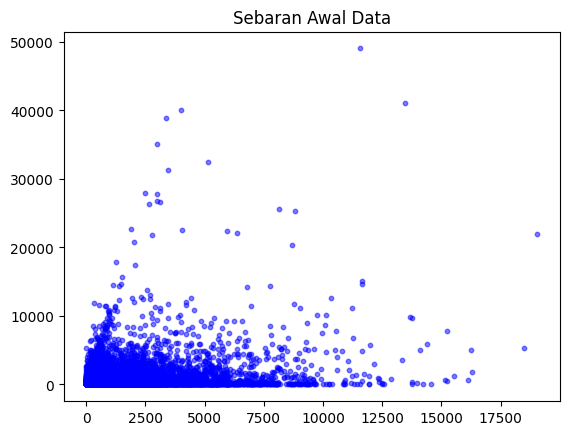

In [6]:
# Pilih 2 fitur utama dan lihat sebaran datanya
df_x = df[['BALANCE', 'PURCHASES']].copy()

plt.scatter(df_x['BALANCE'], df_x['PURCHASES'], s=10, c="blue", alpha=0.5)
plt.title("Sebaran Awal Data")
plt.show()

In [7]:
# Normalisasi data agar skalanya seragam (0-1)
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(df_x)
x_scaled

array([[0.00214779, 0.00194537],
       [0.1681691 , 0.        ],
       [0.13102614, 0.01576625],
       ...,
       [0.00122872, 0.00294456],
       [0.00070669, 0.        ],
       [0.01957178, 0.02229322]], shape=(8950, 2))

In [8]:
# Buat model K-Means dengan 4 cluster
kmeans = KMeans(n_clusters=4, random_state=42)
df_x['kluster'] = kmeans.fit_predict(x_scaled)

df_x.head()

,BALANCE,PURCHASES,kluster
0,40.900749,95.40,3
1,3202.467416,0.00,1
2,2495.148862,773.17,1
3,1666.670542,1499.00,3
4,817.714335,16.00,3


In [9]:
# Evaluasi kualitas cluster dengan Silhouette Score
sil_score = silhouette_score(x_scaled, kmeans.labels_)
print(f"Silhouette Score : {sil_score:.4f}")

Silhouette Score : 0.5791


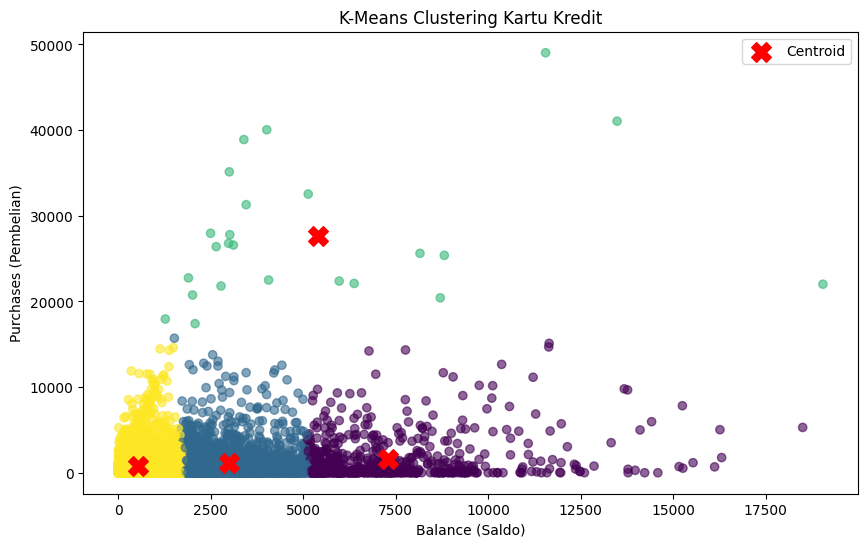

In [10]:
# Kembalikan skala centroid ke nilai asli untuk visualisasi
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

# Visualisasi hasil clustering
plt.figure(figsize=(10,6))
plt.scatter(df_x['BALANCE'], df_x['PURCHASES'], c=df_x['kluster'], cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', label='Centroid')

plt.xlabel('Balance (Saldo)')
plt.ylabel('Purchases (Pembelian)')
plt.title('K-Means Clustering Kartu Kredit')
plt.legend()
plt.show()